In [226]:
import sys 

sys.path.append("../../src/")
from project_imports import *

import numerical_quenches as nq 

from numerical_quenches import groundstate

import TFIM_operators_from_states as op

In [264]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 4*pi/4, 250)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])

In [281]:
taus_free = [.0001,5,15]
g0s = [100,5,2.5]
gfs = [0.0,0.25,0.5]
L = 500

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

g0=1.0
g0=0.0
g0=1.0
g0=0.25
g0=1.0
g0=0.5
g0=1.0
g0=0.0
g0=1.0
g0=0.25
g0=1.0
g0=0.5
g0=1.0
g0=0.0
g0=1.0
g0=0.25
g0=1.0
g0=0.5


In [282]:
def P_vector(n,states):
    return array([op.Px_n(n,s) for s in states])
def Pz_vector(n,states):
    return array([op.Pz_n(n,s) for s in states])

In [283]:
ns = [1,4,8]

dat2 = {}   # Pz
dat1 = {}   # Px

for (tau, gf), states_j in free_states.items():
    dat2[(tau, gf)] = np.array([
        Pz_vector(n, states_j)
        for n in ns
    ])

for (tau, gf), states_j in free_states.items():
    dat1[(tau, gf)] = np.array([
        P_vector(n, states_j)
        for n in ns
    ])

print("Done!")

Done!


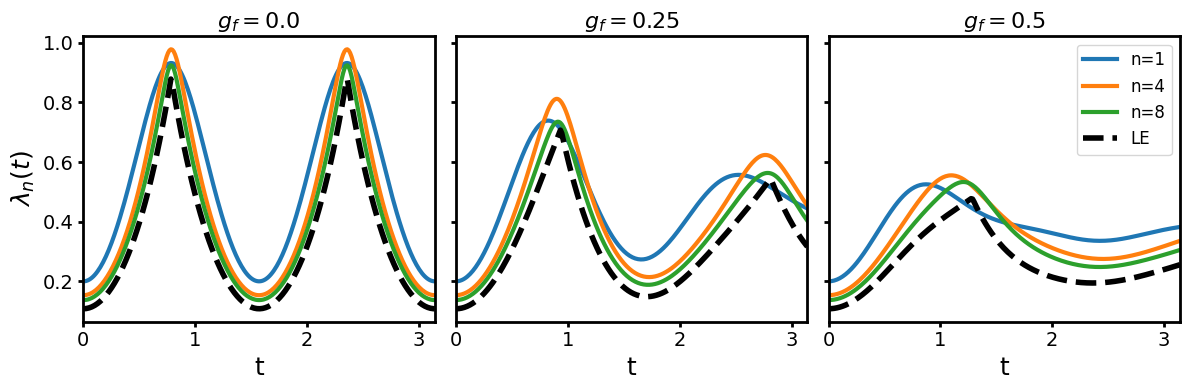

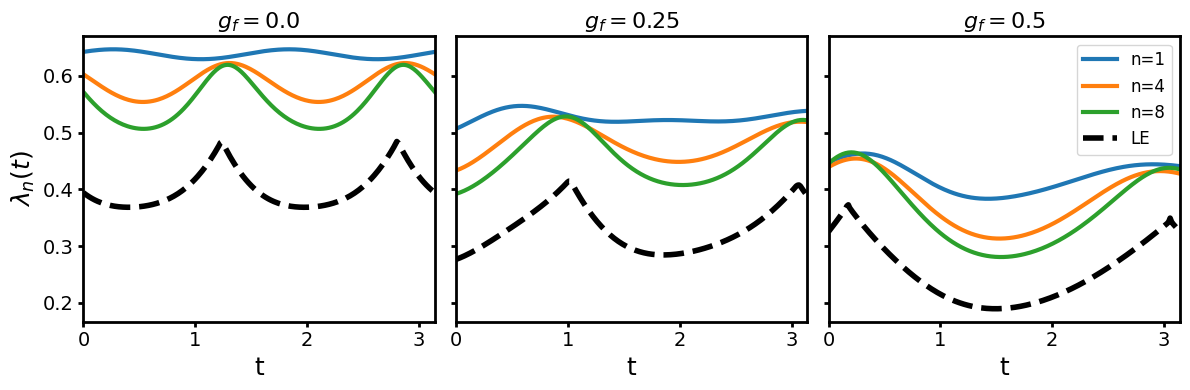

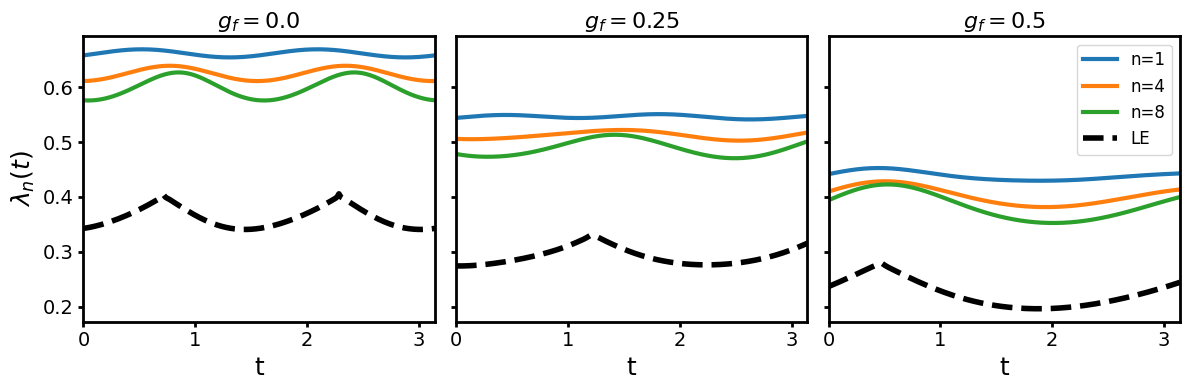

In [284]:
# ---------- style controls ----------
LW        = 3        # line width of curves
LW_LE     = 4        # line width of Loschmidt echo
BORDER_LW = 2        # axis border thickness
FS_LABEL  = 18       # axis label font size
FS_TITLE  = 16       # subplot title font size
FS_TICK   = 14       # tick font size
FS_LEGEND = 12       # legend font size
FIG_SCALE = 4        # width per panel

# ---------- plotting ----------
for tau in taus_free:

    g0 = g0s[taus_free.index(tau)]
    psi_0 = nq.groundstate(g0, L)

    fig, axes = plt.subplots(1, len(gfs),
                             figsize=(FIG_SCALE*len(gfs), FIG_SCALE),
                             sharey=True)

    for j, gf in enumerate(gfs):

        ax = axes[j]

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t - t[0]

        ol = nq.overlap(states_j, psi_0)

        for i, n in enumerate(ns):

            Pz = dat2[(tau, gf)][i]
            ax.plot(t, -np.log(Pz)/n, lw=LW, label=f"n={n}")

        # Loschmidt echo
        ax.plot(t, -np.log(ol)/L, "--k", lw=LW_LE, label="LE")

        ax.set_xlim(t[0], t[-1])
        ax.set_title(rf"$g_f={gf}$", fontsize=FS_TITLE)
        ax.set_xlabel("t", fontsize=FS_LABEL)

        # tick style
        ax.tick_params(labelsize=FS_TICK, width=BORDER_LW)

        # border thickness
        for spine in ax.spines.values():
            spine.set_linewidth(BORDER_LW)

    axes[0].set_ylabel(r"$\lambda_n(t)$", fontsize=FS_LABEL)
    axes[-1].legend(fontsize=FS_LEGEND)

    plt.tight_layout()
    plt.show()

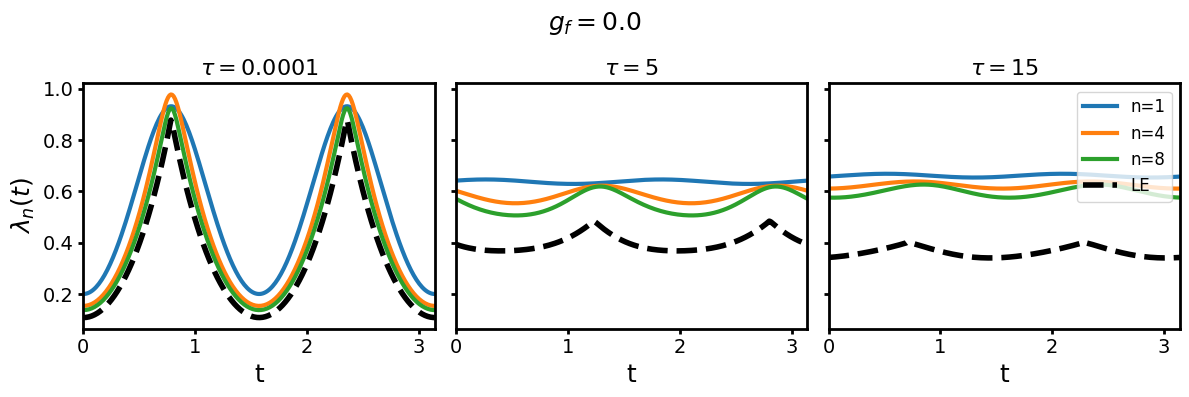

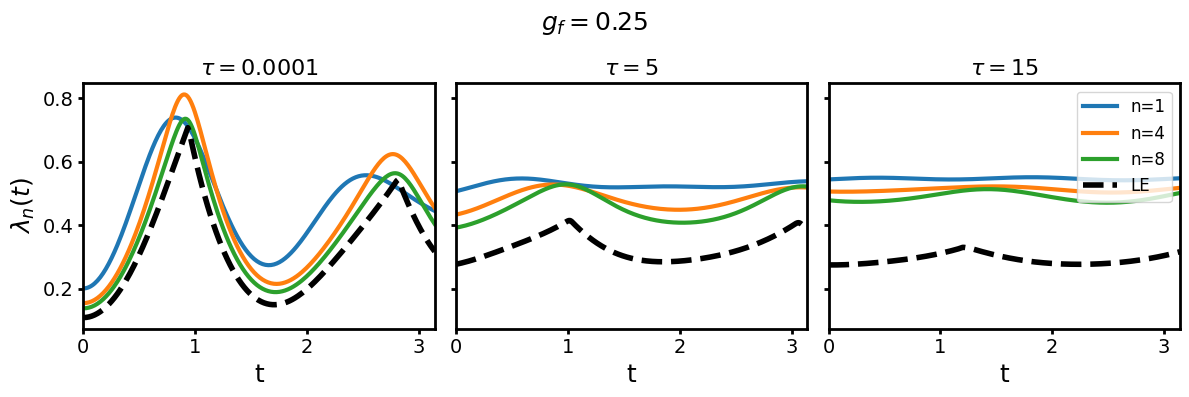

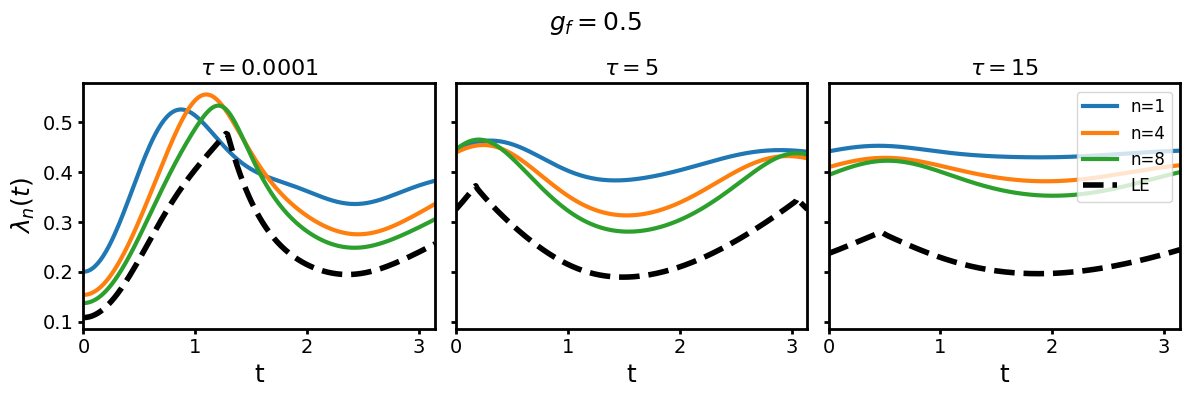

In [286]:
# ---------- style controls ----------
LW        = 3
LW_LE     = 4
BORDER_LW = 2
FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 12
FIG_SCALE = 4

# ---------- plotting ----------
for gf in gfs:

    fig, axes = plt.subplots(1, len(taus_free),
                             figsize=(FIG_SCALE*len(taus_free), FIG_SCALE),
                             sharey=True)

    for j, tau in enumerate(taus_free):

        ax = axes[j]

        g0 = g0s[taus_free.index(tau)]
        psi_0 = nq.groundstate(g0, L)

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t - t[0]

        ol = nq.overlap(states_j, psi_0)

        for i, n in enumerate(ns):

            Pz = dat2[(tau, gf)][i]
            ax.plot(t, -np.log(Pz)/n, lw=LW, label=f"n={n}")

        # Loschmidt echo
        ax.plot(t, -np.log(ol)/L, "--k", lw=LW_LE, label="LE")

        ax.set_xlim(t[0], t[-1])
        ax.set_title(rf"$\tau={tau}$", fontsize=FS_TITLE)
        ax.set_xlabel("t", fontsize=FS_LABEL)

        ax.tick_params(labelsize=FS_TICK, width=BORDER_LW)

        for spine in ax.spines.values():
            spine.set_linewidth(BORDER_LW)

    axes[0].set_ylabel(r"$\lambda_n(t)$", fontsize=FS_LABEL)
    axes[-1].legend(fontsize=FS_LEGEND,loc="upper right")

    plt.suptitle(rf"$g_f={gf}$", fontsize=FS_TITLE+2)

    plt.tight_layout()
    plt.show()

In [235]:
from numpy import gradient as grad

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


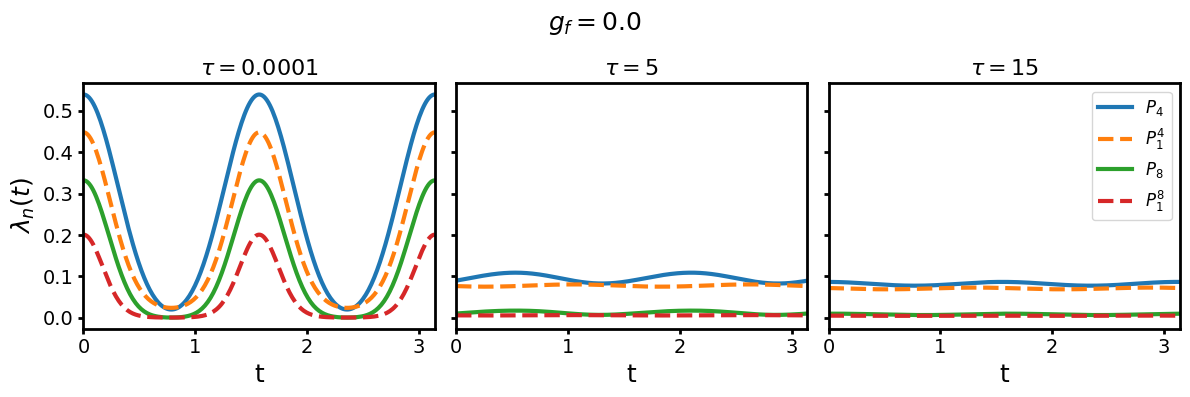

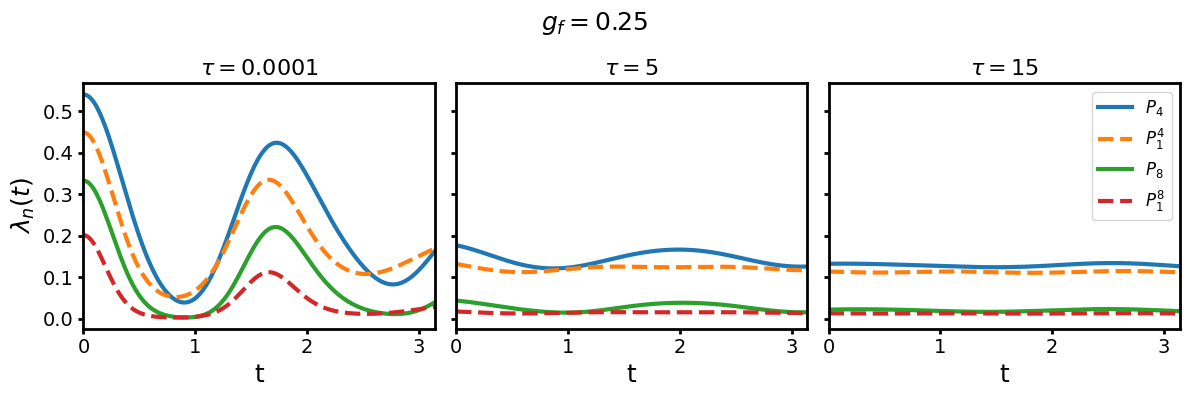

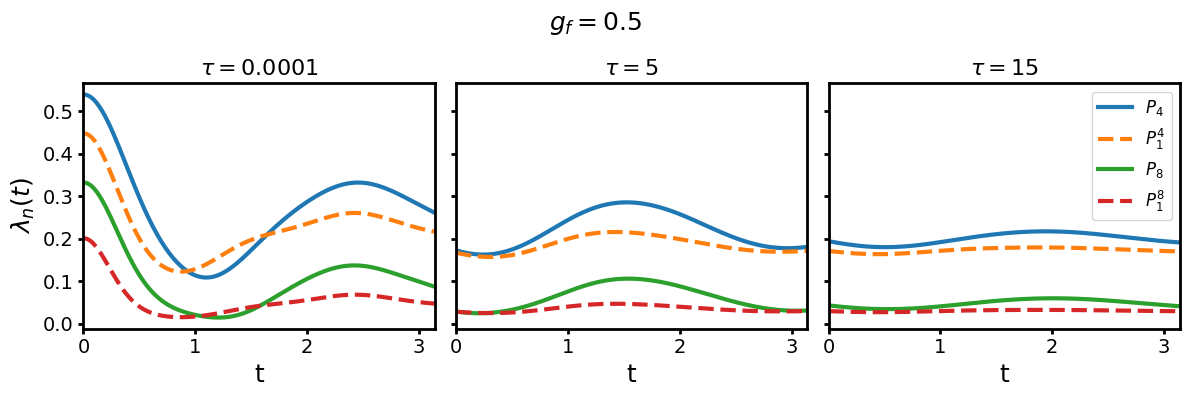

In [298]:
# ---------- style controls ----------
LW        = 3
LW_LE     = 4
BORDER_LW = 2
FS_LABEL  = 18
FS_TITLE  = 16
FS_TICK   = 14
FS_LEGEND = 12
FIG_SCALE = 4

# ---------- plotting ----------
for gf in gfs:

    fig, axes = plt.subplots(1, len(taus_free),
                             figsize=(FIG_SCALE*len(taus_free), FIG_SCALE),
                             sharey=True)

    for j, tau in enumerate(taus_free):

        ax = axes[j]

        g0 = g0s[taus_free.index(tau)]
        psi_0 = nq.groundstate(g0, L)

        states_j = free_states[(tau, gf)]
        t = free_times[(tau, gf)]
        t = t - t[0]

        ol = nq.overlap(states_j, psi_0)

        # P1
        P1 = dat2[(tau, gf)][0]

        for i, n in enumerate(ns):
            if n==1:
                pass
            else:

                Pn = dat2[(tau, gf)][i]

                # actual projector
                ax.plot(t, Pn, lw=LW, label=f"$P_{n}$")

                # P1^n comparison
                ax.plot(t, P1**n, ls="--",lw=LW, label=f"$P_1^{n}$")

        #ax.plot(t, -np.log(ol)/L, "--k", lw=LW_LE, label="LE")

        ax.set_xlim(t[0], t[-1])
        ax.set_title(rf"$\tau={tau}$", fontsize=FS_TITLE)
        ax.set_xlabel("t", fontsize=FS_LABEL)

        ax.tick_params(labelsize=FS_TICK, width=BORDER_LW)

        for spine in ax.spines.values():
            spine.set_linewidth(BORDER_LW)

    axes[0].set_ylabel(r"$\lambda_n(t)$", fontsize=FS_LABEL)
    axes[-1].legend(fontsize=FS_LEGEND, loc="upper right")

    plt.suptitle(rf"$g_f={gf}$", fontsize=FS_TITLE+2)

    plt.tight_layout()
    plt.show()

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


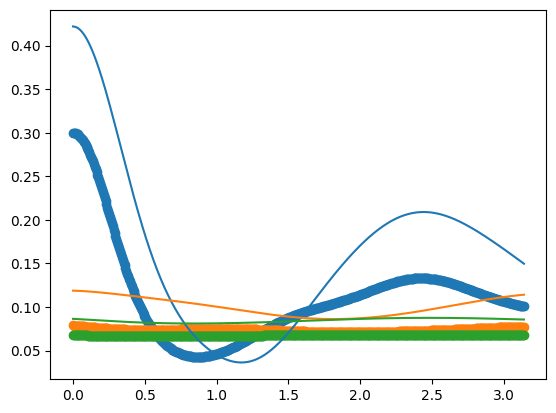

In [237]:
tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)
psi_f = groundstate(gf,L)

y=dat2[(tau,gf)][0]**(6)

scatter(t,y)

y = dat2[(tau,gf)][-1]
plot(t,y)

tau_index = 1
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)
psi_f = groundstate(gf,L)

y=dat2[(tau,gf)][0]**(6)

scatter(t,y)

y = dat2[(tau,gf)][-1]
plot(t,y)


tau_index = 2
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi = groundstate(g0, L)
psi_f = groundstate(gf,L)

y=dat2[(tau,gf)][0]**(6)

scatter(t,y)

y = dat2[(tau,gf)][-1]
plot(t,y)



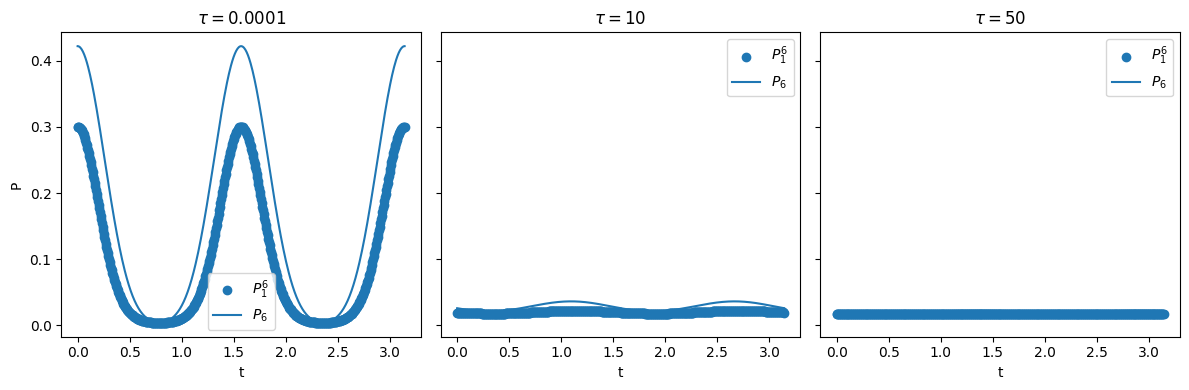

In [225]:
fig, axs = plt.subplots(1, 3, figsize=(12,4), sharey=True)

for ax, tau_index in zip(axs, [0,1,2]):

    tau = taus_free[tau_index]
    g0  = g0s[tau_index]

    psi   = groundstate(g0, L)
    psi_f = groundstate(gf, L)

    t = free_times[(tau, gf)]
    t = t - t[0]

    y_scatter = dat2[(tau,gf)][0]**6
    y_line    = dat2[(tau,gf)][-1]

    ax.scatter(t, y_scatter, label=r"$P_1^6$")
    ax.plot(t, y_line, label=r"$P_6$")

    ax.set_title(rf"$\tau={tau}$")
    ax.set_xlabel("t")
    ax.legend()

axs[0].set_ylabel("P")

plt.tight_layout()
plt.show()

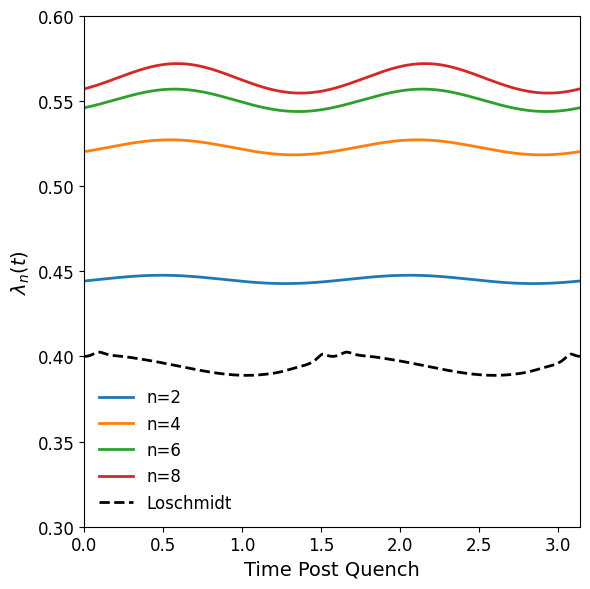

In [157]:
import matplotlib.pyplot as plt
import numpy as np

tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi   = groundstate(g0, L)
psi_f = groundstate(gf, L)

states_j = free_states[(tau, gf)]
t = free_times[(tau, gf)]
t = t - t[0]

fig, ax = plt.subplots(figsize=(6,6))   # square figure

for i, n in enumerate(ns):

    y = dat1[(tau, gf)][i]
    x = dat2[(tau, gf)][i]

    ax.plot(t, (-np.log(x)/(n+1)), lw=2, label=f"n={n}")

ol  = nq.overlap(states_j, psi)
ol2 = nq.overlap(states_j, psi_f)

ax.plot(t, (-np.log(ol)/L), "--k", lw=2, label="Loschmidt")
#ax.plot(t, (-np.log(ol2)/L), "--k", lw=2, label="Loschmidt")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0.3, .6)

ax.set_xlabel("Time Post Quench", fontsize=14)
ax.set_ylabel(r"$\lambda_n(t)$", fontsize=14)

ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

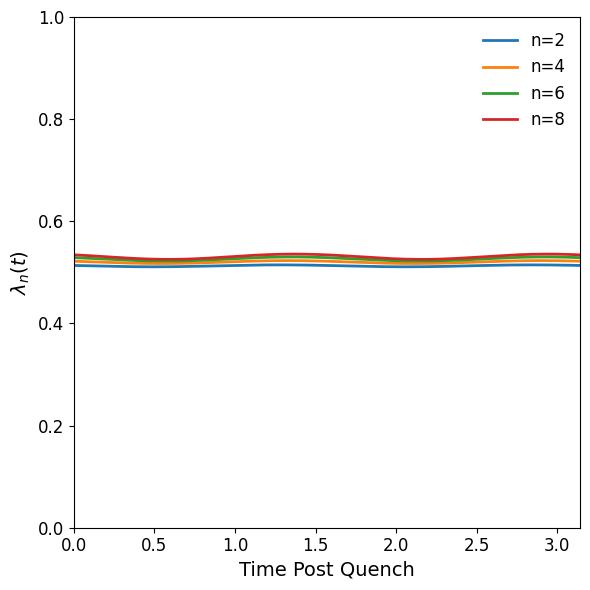

In [170]:
import matplotlib.pyplot as plt
import numpy as np

tau_index = 0
tau = taus_free[tau_index]
g0 = g0s[tau_index]

psi   = groundstate(g0, L)
psi_f = groundstate(gf, L)

states_j = free_states[(tau, gf)]
t = free_times[(tau, gf)]
t = t - t[0]

fig, ax = plt.subplots(figsize=(6,6))   # square figure

for i, n in enumerate(ns):

    y = dat1[(tau, gf)][i]
    x = dat2[(tau, gf)][i]

    ax.plot(t, x**(1/(n)), lw=2, label=f"n={n}")

ol  = nq.overlap(states_j, psi)
ol2 = nq.overlap(states_j, psi_f)

#ax.plot(t, (-np.log(ol)/L), "--k", lw=2, label="Loschmidt")
#ax.plot(t, (-np.log(ol2)/L), "--k", lw=2, label="Loschmidt")

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0., 1)

ax.set_xlabel("Time Post Quench", fontsize=14)
ax.set_ylabel(r"$\lambda_n(t)$", fontsize=14)

ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

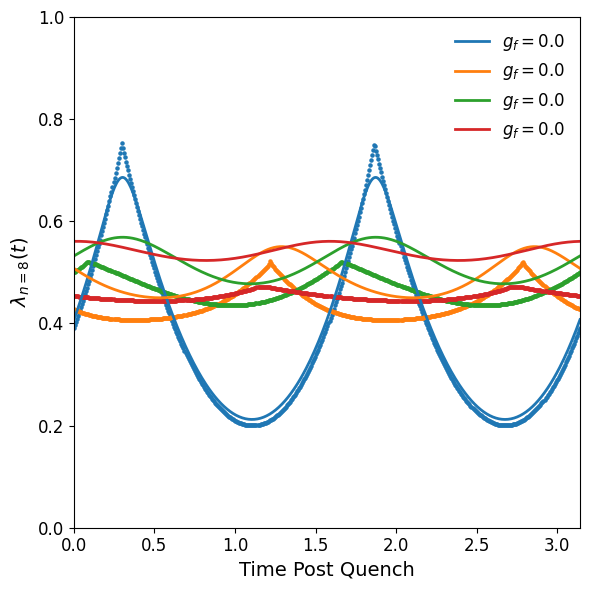

In [139]:
import matplotlib.pyplot as plt
import numpy as np

n_target = 8                 # choose the n you want
i = ns.index(n_target)           # index of that n

fig, ax = plt.subplots(figsize=(6,6))

for tau,g0 in zip(taus_free,g0s):               # loop over all quenches



    psi   = groundstate(g0, L)

    states_j = free_states[(tau, gf)]
    t = free_times[(tau, gf)]
    t = t - t[0]

    x = dat2[(tau, gf)][i]

    ax.plot(t, -np.log(x)/(n_target+1), lw=2, label=f"$g_f={gf}$")

    ol = nq.overlap(states_j, psi)
    ax.scatter(t, -np.log(ol)/L,s=5)

ax.set_xlim(t[0], t[-1])
ax.set_ylim(0,1)

ax.set_xlabel("Time Post Quench", fontsize=14)
ax.set_ylabel(rf"$\lambda_{{n={n_target}}}(t)$", fontsize=14)

ax.legend(frameon=False, fontsize=12)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [ ]:
gs = np.linspace(0,1,5)
psis = [nq.groundstate(g,L) for g in gs]



In [121]:
ns= [1,2,3,4,5,6]
dat=[]
for psi,g in zip(psis,gs):
    dat.append([op.Px_n(ni,psi) for ni in ns])
dat= array(dat)

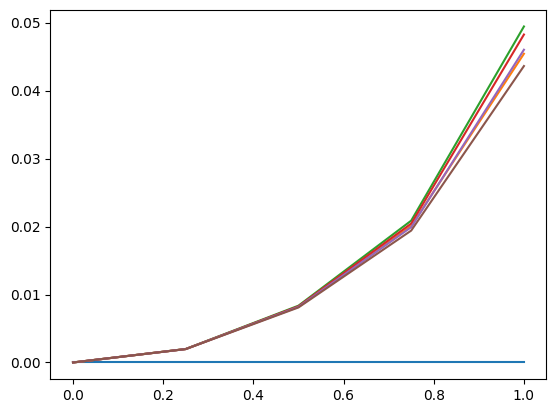

In [124]:
for d,n in zip(dat.T,ns):
    plot(gs,abs(1/2-d)/n)